# IMT 573 - Lab 3 - Advanced Visualization

### Instructions

Before beginning this assignment, please ensure you have access to a working instance of Jupyter Notebooks with Python 3.

1. First, replace the “YOUR NAME HERE” text in the next cell with your own full name. Any collaborators must also be listed in this cell.

2. Be sure to include well-documented (e.g. commented) code cells, figures, and clearly written text  explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy – you do no need four different visualizations of the same pattern.

3. Collaboration on problem sets and labs is fun, useful, and encouraged. However, each student must turn in an individual write-up in their own words as well as code/work that is their own. Regardless of whether you work with others, what you turn in must be your own work; this includes code and interpretation of results. The names of all collaborators must be listed on each assignment. Do not copy-and-paste from other students’ responses or code - your code should never be on any other student's screen or machine.

4. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

Name: YOUR NAME HERE

Collaborators: 

In this module, we have focused on exploring data. Visualization is a great way to do this. Let’s play around with visualization in this lab. To accomplish many of the visualization tasks in the exercise, you will need to also practice newly-acquired data summarization and manipulation skills.

The data we will use in this lab comes from the Million Song Dataset. The Million Song Dataset is a collaboration between the Echo Nest and LabROSA, a laboratory working towards intelligent machine listening. The project was also funded in part by the National Science Foundation of America (NSF) to provide a large data set to evaluate research related to algorithms and information retrieval. 

We will use a subset of this data created by Ryan Whitcomb, rwhit94@vt.edu, which contains data on 10,000 songs. The data contains standard information about the songs such as artist name, title, and year released. Additionally, the data contains more advanced information; for example, the length of the song, how many musical bars long the song is,
and how long the fade in to the song was. You can find more information on the various data elements [here](https://corgis-edu.github.io/corgis/csv/music/)

To start, import the data from `music.csv` into a pandas DataFrame.

http://millionsongdataset.com/

*Thierry Bertin-Mahieux, Daniel P.W. Ellis, Brian Whitman, and Paul Lamere. The Million Song Dataset. In Proceedings of the 12th International Society for Music Information Retrieval Conference (ISMIR 2011), 2011.*

In [6]:
import pandas as pd
data = pd.read_csv("music.csv")

In [7]:
data.head()

,artist.familiarity,artist.hotttnesss,artist.id,artist.latitude,artist.location,artist.longitude,artist.name,artist.similar,artist.terms,artist.terms_freq,...,song.mode,song.mode_confidence,song.start_of_fade_out,song.tatums_confidence,song.tatums_start,song.tempo,song.time_signature,song.time_signature_confidence,song.title,song.year
0,0.581794,0.401998,ARD7TVE1187B99BFB1,0.00000,0,0.00000,Casual,0.0,hip hop,1.000000,...,0,0.636,218.932,0.779,0.28519,92.198,4.0,0.778,0,0
1,0.630630,0.417500,ARMJAGH1187FB546F3,35.14968,0,-90.04892,The Box Tops,0.0,blue-eyed soul,1.000000,...,0,0.430,137.915,0.969,0.20627,121.274,4.0,0.384,0,1969
2,0.487357,0.343428,ARKRRTF1187B9984DA,0.00000,0,0.00000,Sonora Santanera,0.0,salsa,1.000000,...,1,0.565,172.304,0.482,0.42132,100.070,1.0,0.000,0,0
3,0.630382,0.454231,AR7G5I41187FB4CE6C,0.00000,0,0.00000,Adam Ant,0.0,pop rock,0.988584,...,1,0.749,217.124,0.601,0.56254,119.293,4.0,0.000,0,1982
4,0.651046,0.401724,ARXR32B1187FB57099,0.00000,0,0.00000,Gob,0.0,pop punk,0.887288,...,1,0.371,198.699,1.000,0.13576,129.738,4.0,0.562,0,2007


### Problem 1: Inspection

First, inspect the data. You can use functions such as `head()`, `tail()`, and `describe()`. to help you get a sense of what is contained in the data. What do you notice? Where may there be some issues with the data?

### Problem 2: Pose a question

In [8]:
import numpy as np 

# get overall size of data set 
print("Shape:", data.shape)
print("\nFirst 5 columns:", list(data.columns[:5]))
print("\nAll columns:", list(data.columns))

# quick look at data first and last rows
display(data.head())
display(data.tail())

# summay of the numeric columns
display(data.describe())

# missing values 
nulls = data.isna().sum().sort_values(ascending=False)
print("\nMissing values by column (top 10):")
display(nulls.head(10))

# year sanity check 
year = pd.to_numeric(data["song.year"], errors="coerce")
print("\nYear min/max (before cleaning):", np.nanmin(year), np.nanmax(year))
print("Zero years count:", (year == 0).sum())

Shape: (10000, 35)

First 5 columns: ['artist.familiarity', 'artist.hotttnesss', 'artist.id', 'artist.latitude', 'artist.location']

All columns: ['artist.familiarity', 'artist.hotttnesss', 'artist.id', 'artist.latitude', 'artist.location', 'artist.longitude', 'artist.name', 'artist.similar', 'artist.terms', 'artist.terms_freq', 'release.id', 'release.name', 'song.artist_mbtags', 'song.artist_mbtags_count', 'song.bars_confidence', 'song.bars_start', 'song.beats_confidence', 'song.beats_start', 'song.duration', 'song.end_of_fade_in', 'song.hotttnesss', 'song.id', 'song.key', 'song.key_confidence', 'song.loudness', 'song.mode', 'song.mode_confidence', 'song.start_of_fade_out', 'song.tatums_confidence', 'song.tatums_start', 'song.tempo', 'song.time_signature', 'song.time_signature_confidence', 'song.title', 'song.year']


,artist.familiarity,artist.hotttnesss,artist.id,artist.latitude,artist.location,artist.longitude,artist.name,artist.similar,artist.terms,artist.terms_freq,...,song.mode,song.mode_confidence,song.start_of_fade_out,song.tatums_confidence,song.tatums_start,song.tempo,song.time_signature,song.time_signature_confidence,song.title,song.year
0,0.581794,0.401998,ARD7TVE1187B99BFB1,0.00000,0,0.00000,Casual,0.0,hip hop,1.000000,...,0,0.636,218.932,0.779,0.28519,92.198,4.0,0.778,0,0
1,0.630630,0.417500,ARMJAGH1187FB546F3,35.14968,0,-90.04892,The Box Tops,0.0,blue-eyed soul,1.000000,...,0,0.430,137.915,0.969,0.20627,121.274,4.0,0.384,0,1969
2,0.487357,0.343428,ARKRRTF1187B9984DA,0.00000,0,0.00000,Sonora Santanera,0.0,salsa,1.000000,...,1,0.565,172.304,0.482,0.42132,100.070,1.0,0.000,0,0
3,0.630382,0.454231,AR7G5I41187FB4CE6C,0.00000,0,0.00000,Adam Ant,0.0,pop rock,0.988584,...,1,0.749,217.124,0.601,0.56254,119.293,4.0,0.000,0,1982
4,0.651046,0.401724,ARXR32B1187FB57099,0.00000,0,0.00000,Gob,0.0,pop punk,0.887288,...,1,0.371,198.699,1.000,0.13576,129.738,4.0,0.562,0,2007


,artist.familiarity,artist.hotttnesss,artist.id,artist.latitude,artist.location,artist.longitude,artist.name,artist.similar,artist.terms,artist.terms_freq,...,song.mode,song.mode_confidence,song.start_of_fade_out,song.tatums_confidence,song.tatums_start,song.tempo,song.time_signature,song.time_signature_confidence,song.title,song.year
9995,0.722571,0.499826,AR4C6V01187FB3BAF4,39.55792,0,-7.84481,Moonspell,0.0,sympho black metal,0.999765,...,1,0.540,386.194,0.224,0.22262,140.185,4.0,0.099,0,1998
9996,0.511663,0.409779,AR9JLBU1187B9AAEC4,-33.96243,0,25.62326,Danny Williams,0.0,ballad,0.915417,...,1,0.398,163.463,0.604,0.07692,77.072,3.0,0.597,0,1998
9997,0.433508,0.289903,ARS1DCR1187B9A4A56,0.00000,0,0.00000,Winston Reedy,0.0,lovers rock,0.960115,...,1,0.565,186.015,1.000,0.27924,118.123,4.0,0.205,0,0
9998,0.334457,0.216829,ARAGMIV11F4C843F78,0.00000,0,0.00000,"Myrick ""Freeze"" Guillory",0.0,zydeco,1.000000,...,1,0.503,300.826,0.421,0.28192,137.663,4.0,0.000,0,0
9999,0.609182,0.509243,ARYXOV81187B99831D,0.00000,0,0.00000,Seventh Day Slumber,0.0,christian rock,0.926220,...,0,0.406,193.167,0.710,0.20535,150.575,4.0,0.317,0,2005


,artist.familiarity,artist.hotttnesss,artist.latitude,artist.location,artist.longitude,artist.similar,artist.terms_freq,release.id,release.name,song.artist_mbtags,...,song.mode,song.mode_confidence,song.start_of_fade_out,song.tatums_confidence,song.tatums_start,song.tempo,song.time_signature,song.time_signature_confidence,song.title,song.year
count,10000.000000,10000.000000,10000.000000,10000.000,10000.000000,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.565230,0.385552,13.904283,0.078,-23.923863,0.0,2.248903e+02,371024.058400,23.096000,0.000033,...,0.691000,0.477765,229.883436,0.507875,0.299886,122.900913,3.564443,0.599785,10.011400,934.704600
std,0.160528,0.143647,20.356379,7.800,43.723359,0.0,2.239216e+04,236777.828209,1322.901526,0.003330,...,0.462104,0.191269,112.024303,0.332357,0.510925,35.204746,1.266620,8.991567,945.486852,996.650657
min,0.000000,0.000000,-41.280540,0.000,-162.436500,0.0,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,-21.394000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.467570,0.325266,0.000000,0.000,-73.948880,0.0,9.476125e-01,172858.000000,0.000000,0.000000,...,0.000000,0.360000,168.855750,0.237000,0.110692,96.959500,3.000000,0.097750,0.000000,0.000000
50%,0.563584,0.380742,0.000000,0.000,0.000000,0.0,9.999728e-01,333103.000000,0.000000,0.000000,...,1.000000,0.487000,213.864500,0.500000,0.191520,120.156500,4.000000,0.551000,0.000000,0.000000
75%,0.668020,0.453858,34.419250,0.000,0.000000,0.0,1.000000e+00,573532.500000,0.000000,0.000000,...,1.000000,0.606000,266.274750,0.774250,0.294743,144.006750,4.000000,0.864000,0.000000,2000.000000
max,1.000000,1.082503,69.651020,780.000,174.767140,0.0,2.239217e+06,823599.000000,85555.000000,0.333000,...,1.000000,1.000000,1813.426000,9.227560,12.245830,262.828000,7.000000,898.891000,94496.000000,2010.000000



Missing values by column (top 10):


artist.terms              5
artist.familiarity        0
song.mode_confidence      0
song.hotttnesss           0
song.id                   0
song.key                  0
song.key_confidence       0
song.loudness             0
song.mode                 0
song.start_of_fade_out    0
dtype: int64


Year min/max (before cleaning): 0 2010
Zero years count: 5320


Propose a question to guide your analysis. For example, you might ask _does the average hotness scores of songs change over time?_ Or perhaps, _what is the relationship between song duration and tempo?_ You can use one of these questions or develop your own. State which question you want to answer.

What is song hotttnesss you ask? According to the dataset description, it is a measure of the song’s popularity, when downloaded (in December 2010). And measured on a scale of 0 to 1.

** propose quetsion **

  Is there a relationship between artist familiarity and how hot their songs are?



### Problem 3: Visualization

Create two visualizations to help gain insight into your question. Be sure to explain the visuals you create and what you take away from them.

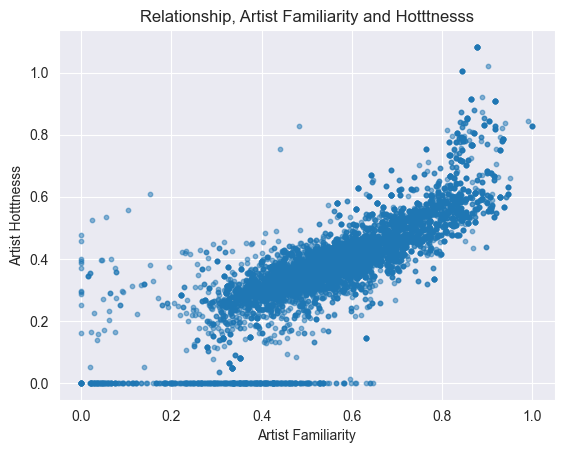

/var/folders/1s/bsdc29gj1x16g8m2s5syblpm0000gn/T/ipykernel_40280/3085672115.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_bin = df.groupby("familiarity_bin")["artist.hotttnesss"].mean()


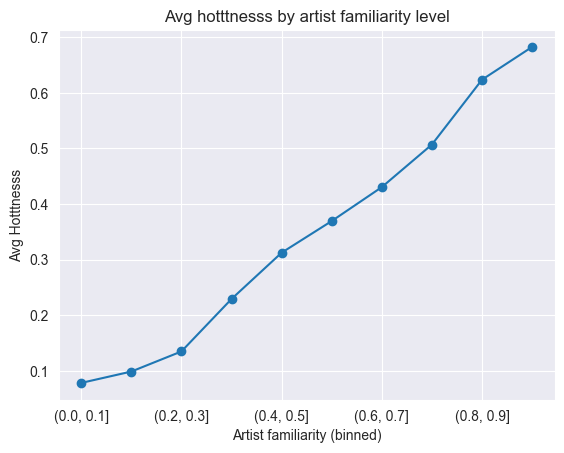

In [9]:
# To look at the relationbetween the familiarity and hottness i have 2 visualizations--> scatter plot of the relationship, and a line plot of avg hottness acrss familiarity levels 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Use  the two columns in question 
df = data[["artist.familiarity", "artist.hotttnesss"]].copy()

# Clean, convert to numbers, drop missing
df["artist.familiarity"] = pd.to_numeric(df["artist.familiarity"], errors="coerce")
df["artist.hotttnesss"] = pd.to_numeric(df["artist.hotttnesss"], errors="coerce")
df = df.dropna()

# Scatter plot
plt.figure()
plt.scatter(df["artist.familiarity"], df["artist.hotttnesss"], s=10, alpha=0.5)
plt.xlabel("Artist Familiarity")
plt.ylabel("Artist Hotttnesss")
plt.title("Relationship, Artist Familiarity and Hotttnesss")
plt.show()

# Line plot  average hotttnesss by familiarity
# Group artists into bins of familiarity 
df["familiarity_bin"] = pd.cut(df["artist.familiarity"], bins=np.linspace(0, 1, 11))
avg_by_bin = df.groupby("familiarity_bin")["artist.hotttnesss"].mean()

plt.figure()
avg_by_bin.plot(kind="line", marker="o")
plt.xlabel("Artist familiarity (binned)")
plt.ylabel("Avg Hotttnesss")
plt.title("Avg hotttnesss by artist familiarity level")
plt.show()

